In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [22]:
df = pd.DataFrame(columns=["Model","Data", "Odds Ratio", "k", "Total", "Positive", "Negative"])

for file in os.listdir("./results/"):
    if not file.endswith(".txt") or not file.startswith("QFinder_"):
        continue
    file_name = file.split(".txt")[0]
    file_args = file_name.split("_")
    data = file_args[1]
    odds_ratio = (file_args[2])
    k = int(file_args[3])

    with open(f"./results/{file}", "r") as f:
        lines = f.readlines()
        total = float(lines[0].split(": ")[1])
        positive = float(lines[1].split(": ")[1])
        negative = float(lines[2].split(": ")[1])
        df.loc[len(df)] = ["QFinder", data, odds_ratio, k, total, positive, negative]


In [23]:
df.head()

,Model,Data,Odds Ratio,k,Total,Positive,Negative
0,QFinder,Cardio,6,160,1.0,1.0,1.0
1,QFinder,Depression,3,160,1.0,1.0,1.0
2,QFinder,Car,3,190,1.0,1.0,1.0
3,QFinder,Depression,3,340,1.0,1.0,1.0
4,QFinder,Cardio,1.2,70,1.0,1.0,1.0


In [24]:
df["Youden's J index"] = df["Positive"] - df["Negative"]

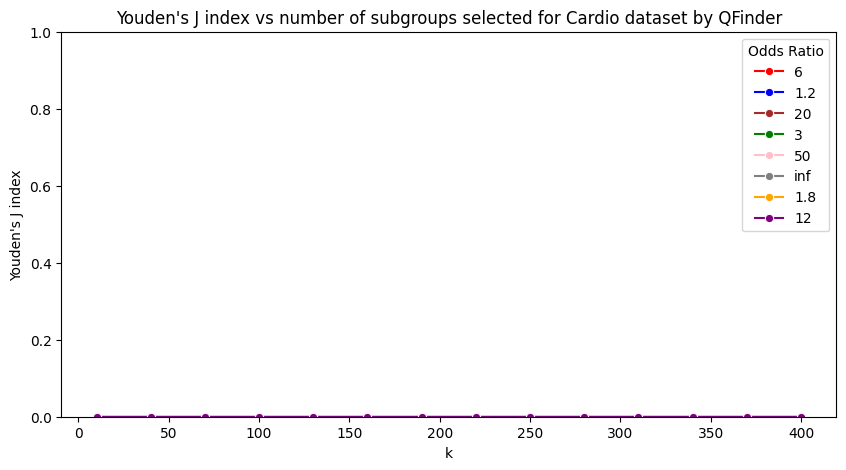

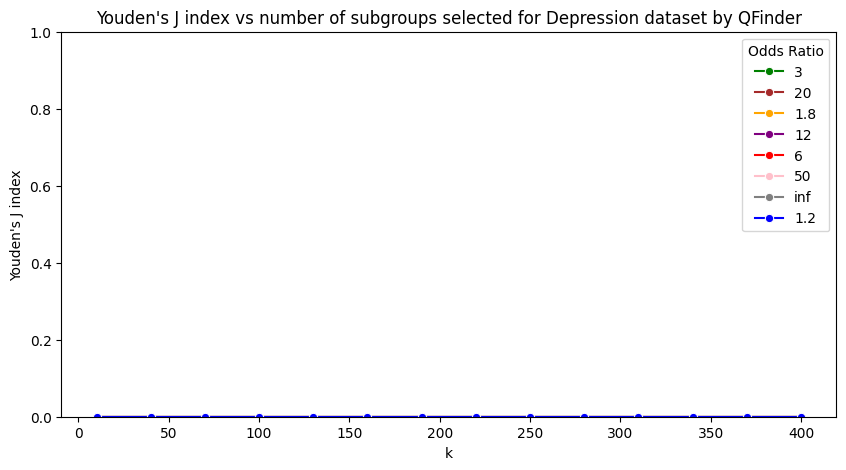

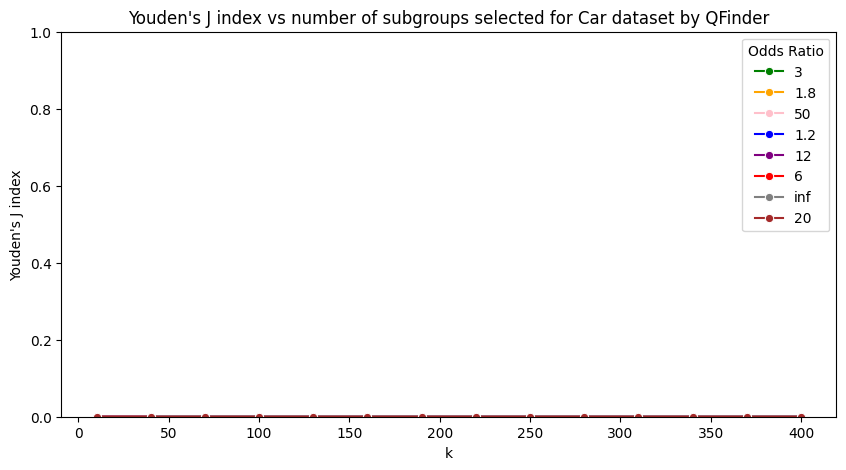

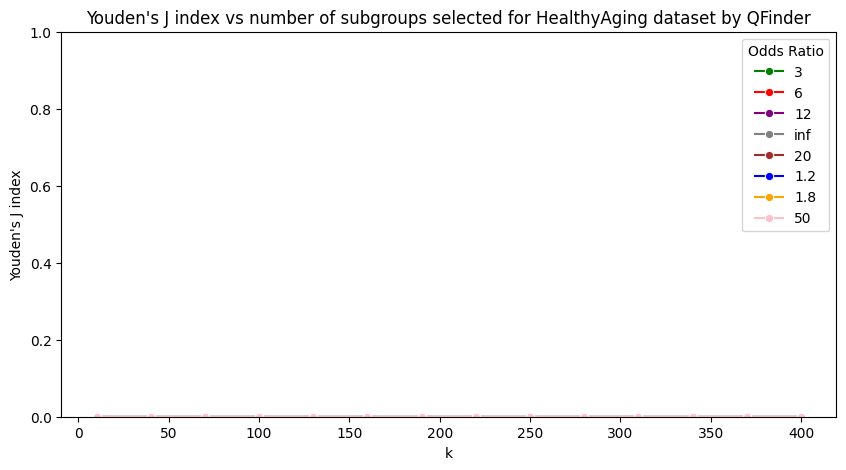

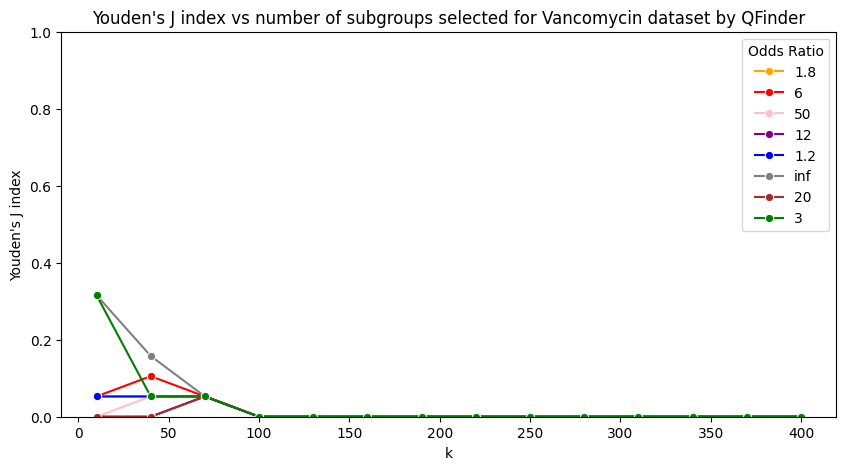

In [25]:
color_map = {
    "1.2" : "blue",
    "1.8" : "orange",
    "3" : "green",
    "6" : "red",
    "12" : "purple",
    "20" : "brown",
    "50" : "pink",
    "inf" : "gray"
}

for d in df["Data"].unique():
    fig = plt.figure(figsize=(10, 5))
    sns.lineplot(x = "k", y = "Youden's J index", hue = "Odds Ratio", data = df[df["Data"] == d], marker="o", palette=color_map)
    plt.title(f"Youden's J index vs number of subgroups selected for {d} dataset by QFinder")
    plt.ylim(0, 1)
    plt.savefig(f"./plots/QFinder_{d}_Youden.png")